# EDA & Data Preprocessing



1. Dataset Loading and Initial Exploration

In [1]:
%pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
from ucimlrepo import fetch_ucirepo, list_available_datasets

# check which datasets can be imported
list_available_datasets()

# import dataset
heart_disease = fetch_ucirepo(id=45)
# alternatively: fetch_ucirepo(name='Heart Disease')

# access data
X = heart_disease.data.features
y = heart_disease.data.targets

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [4]:
all_columns = heart_disease.variables['name'].tolist()

df_X = pd.DataFrame(X, columns=all_columns[:-1])
df_y = pd.DataFrame(y, columns=[all_columns[-1]])

df = pd.concat([df_X, df_y], axis=1)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [ ]:
df.shape

(303, 14)

In [ ]:
list(df.columns)
# Target Column Variable -> num
# 0 → No heart disease
# 1, 2, 3, 4 → Presence of heart disease

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num']

In [ ]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
df.value_counts()

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca   thal  num
77   1    4   125       304   0    2        162      1      0.0      1      3.0  3.0   4      1
29   1    2   130       204   0    2        202      0      0.0      1      0.0  3.0   0      1
34   0    2   118       210   0    0        192      0      0.7      1      0.0  3.0   0      1
     1    1   118       182   0    2        174      0      0.0      1      0.0  3.0   0      1
35   0    4   138       183   0    0        182      0      1.4      1      0.0  3.0   0      1
                                                                                             ..
39   1    4   118       219   0    0        140      0      1.2      2      0.0  7.0   3      1
          3   140       321   0    2        182      0      0.0      1      0.0  3.0   0      1
     0    3   138       220   0    0        152      0      0.0      2      0.0  3.0   0      1
              94        199   0    0        179      0      0.0      1      0.0  3.0   0      1
38   1    1   120       231   0    0        182      1      3.8      2      0.0  7.0   4      1
Name: count, Length: 297, dtype: int64

In [ ]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,NumMajorVessels,Thalassemia,HeartDisease
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


2. Column Renaming and Feature Descriptions

In [ ]:
# Rename dataset columns to more descriptive names
df = df.rename(columns={
    "age": "Age",                       # Age of the patient (in years)
    "sex": "Sex",                       # Sex (0 = female, 1 = male)
    "cp": "ChestPainType",              # Type of chest pain (4 categories: typical angina, atypical, non-anginal, asymptomatic)
    "trestbps": "RestingBP",            # Resting blood pressure (in mm Hg)
    "chol": "Cholesterol",              # Serum cholesterol level (mg/dl)
    "fbs": "FastingBS",                 # Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
    "restecg": "RestingECG",            # Resting electrocardiographic results (0–2 values)
    "thalach": "MaxHR",                 # Maximum heart rate achieved
    "exang": "ExerciseAngina",          # Exercise induced angina (1 = yes, 0 = no)
    "oldpeak": "Oldpeak",               # ST depression induced by exercise relative to rest
    "slope": "ST_Slope",                # Slope of the peak exercise ST segment (0–2)
    "ca": "NumMajorVessels",            # Number of major vessels (0–3) colored by fluoroscopy
    "thal": "Thalassemia",              # Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)
    "num": "HeartDisease"               # Target variable: heart disease (0 = no disease, 1–4 = disease)
})

In [ ]:
list(df.columns)

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'NumMajorVessels',
 'Thalassemia',
 'HeartDisease']

In [ ]:
# Make a Copy of The Original Dataset Before do any Further Processes
df_copy = df.copy()

3. Check for Missing Values

In [ ]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


4. Fill the Missing Values with Mode ( Most Frequent Value )


In [ ]:
df = df.fillna(df.mode())

In [ ]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
# Make a copy from the original dataset before moving in any further steps
df_copy = df.copy()

5. Convert Features Data Types

In [ ]:
df["NumMajorVessels"] = df["NumMajorVessels"].astype(int)
df["Thalassemia"] = df["Thalassemia"].astype(int)

In [ ]:
df[["NumMajorVessels", "Thalassemia"]].head()

,NumMajorVessels,Thalassemia
0,0,6
1,3,3
2,2,7
3,0,3
4,0,3


6. Check for Duplicate Records

In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


7. Transform Categorical Features into Numeric (One-Hot Encoding)

In [ ]:
categorical_cols = ["Thalassemia", "ChestPainType", "RestingECG", "ST_Slope"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [ ]:
df_encoded.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,NumMajorVessels,HeartDisease,Thalassemia_6,Thalassemia_7,ChestPainType_2,ChestPainType_3,ChestPainType_4,RestingECG_1,RestingECG_2,ST_Slope_2,ST_Slope_3
0,63,1,145,233,1,150,0,2.3,0,0,True,False,False,False,False,False,True,False,True
1,67,1,160,286,0,108,1,1.5,3,2,False,False,False,False,True,False,True,True,False
2,67,1,120,229,0,129,1,2.6,2,1,False,True,False,False,True,False,True,True,False
3,37,1,130,250,0,187,0,3.5,0,0,False,False,False,True,False,False,False,False,True
4,41,0,130,204,0,172,0,1.4,0,0,False,False,True,False,False,False,True,False,False


8. Standardize Numerical Features for Modeling

In [ ]:
numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [ ]:
df_encoded[numerical_cols].head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
0,0.948726,0.757525,-0.264900,0.017197,1.087338
1,1.392002,1.611220,0.760415,-1.821905,0.397182
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147
3,-1.932564,-0.096170,0.063974,1.637359,2.122573
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912


In [ ]:
# ================================================
# Feature Types in the Dataset
# ================================================

# -> Continuous / Numeric Features
# Age
# RestingBP
# Cholesterol
# MaxHR
# Oldpeak

# -> Binary Features
# Sex (0 = female, 1 = male)
# FastingBS
# ExerciseAngina
# HeartDisease (target)

# -> Discrete / Ordinal Features
# NumMajorVessels

# -> One-Hot Encoded Categorical Features
# Thalassemia_6, Thalassemia_7
# ChestPainType_2, ChestPainType_3, ChestPainType_4
# RestingECG_1, RestingECG_2
# ST_Slope_2, ST_Slope_3

9. Conduct Exploratory Data Analysis (EDA) with histograms, correlation heatmaps, and boxplots.

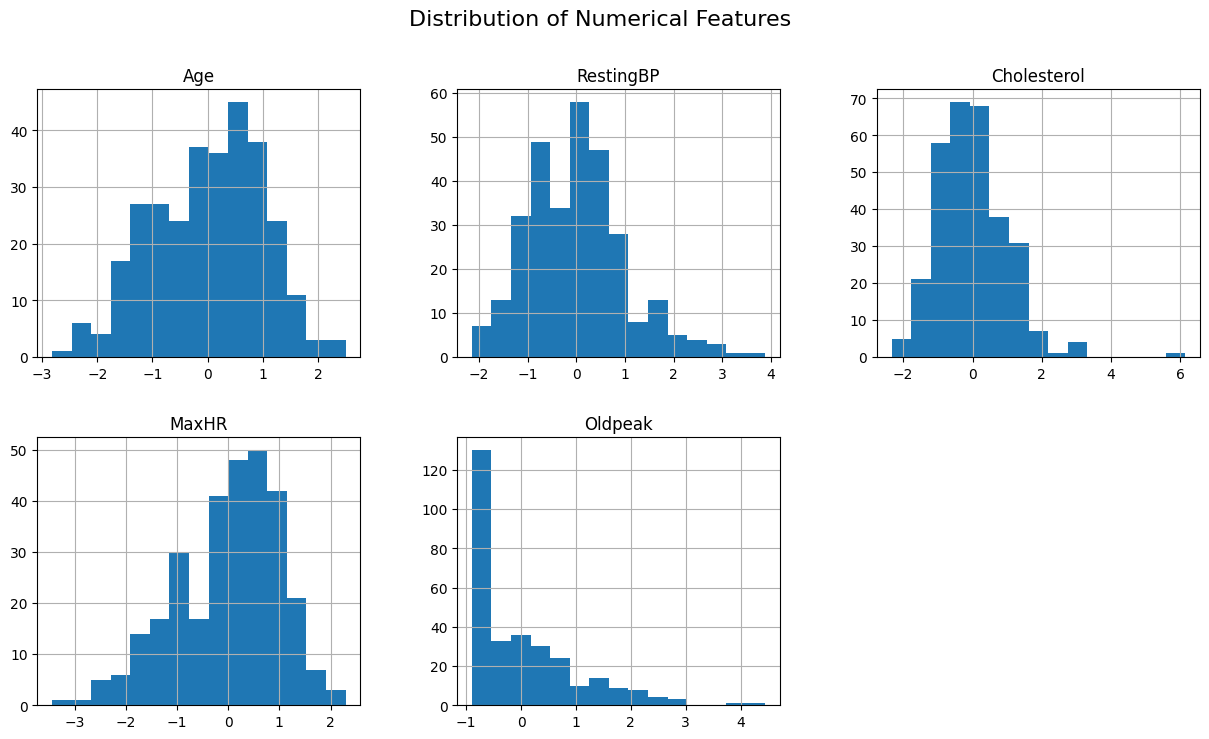

In [ ]:
numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

df_encoded[numerical_cols].hist(bins=15, figsize=(15,8), layout=(2,3))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


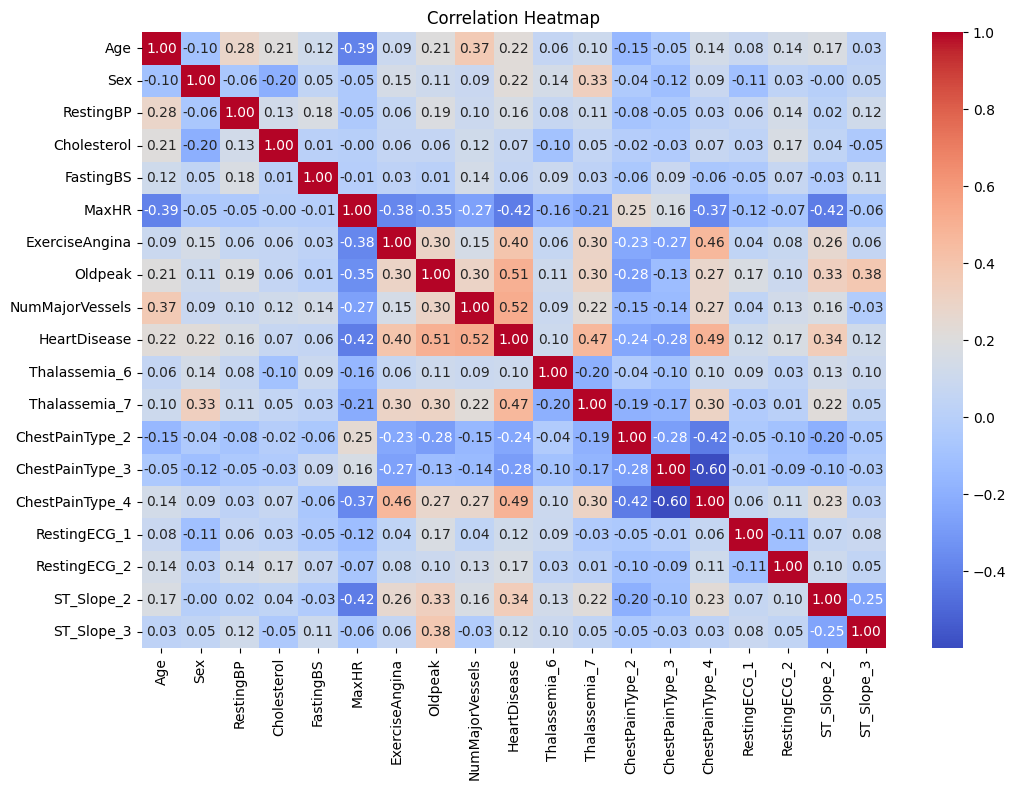

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


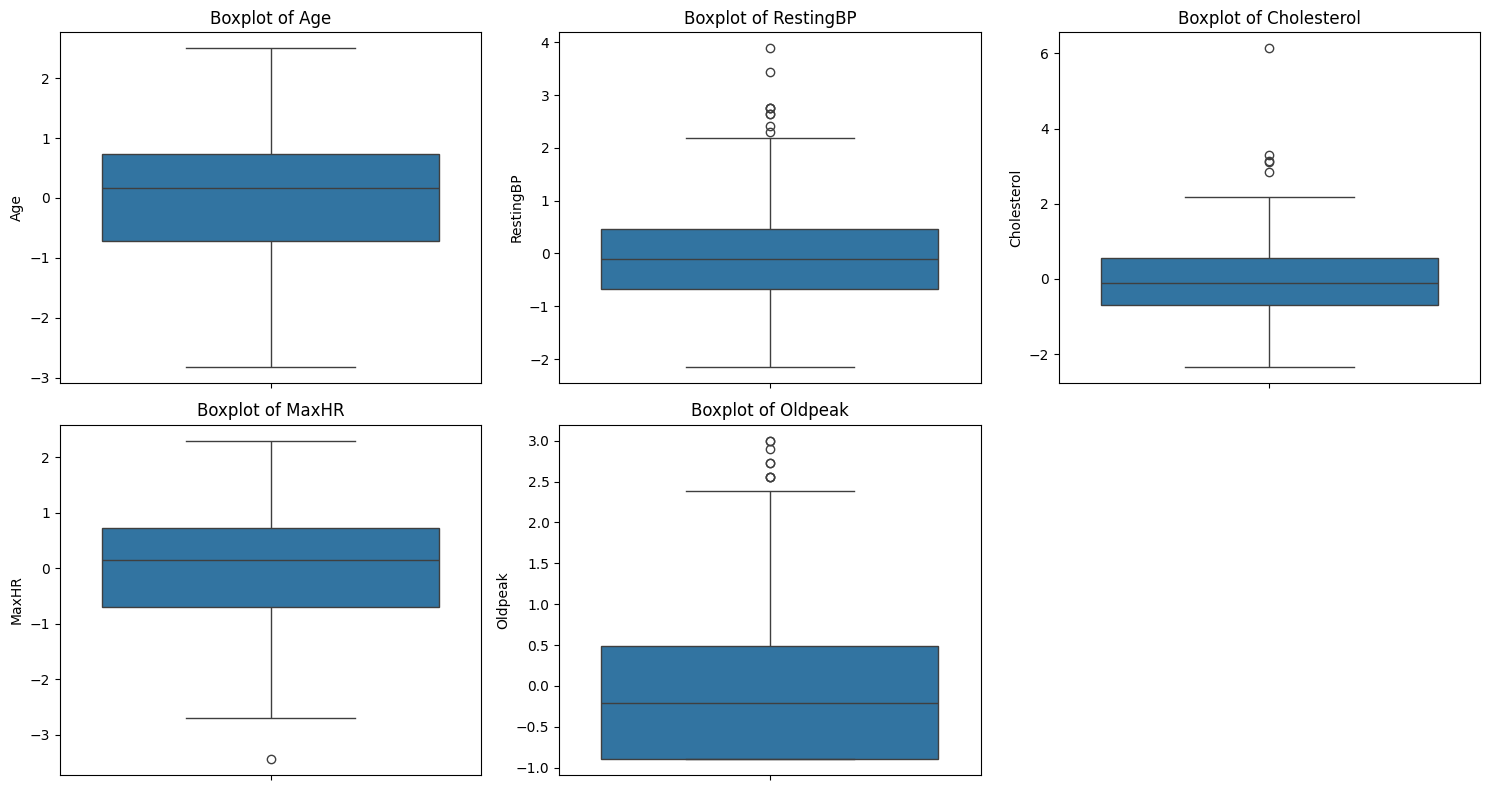

In [ ]:
plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_encoded[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [ ]:
# RestingBP: cap values between 5th and 95th percentiles
df_encoded["RestingBP"] = df_encoded["RestingBP"].clip(
    lower=df_encoded["RestingBP"].quantile(0.05),
    upper=df_encoded["RestingBP"].quantile(0.95)
)

# Cholesterol: cap values between 5th and 95th percentiles
df_encoded["Cholesterol"] = df_encoded["Cholesterol"].clip(
    lower=df_encoded["Cholesterol"].quantile(0.05),
    upper=df_encoded["Cholesterol"].quantile(0.95)
)

# Oldpeak: cap values between 5th and 95th percentiles
df_encoded["Oldpeak"] = df_encoded["Oldpeak"].clip(
    lower=df_encoded["Oldpeak"].quantile(0.05),
    upper=df_encoded["Oldpeak"].quantile(0.95)
)

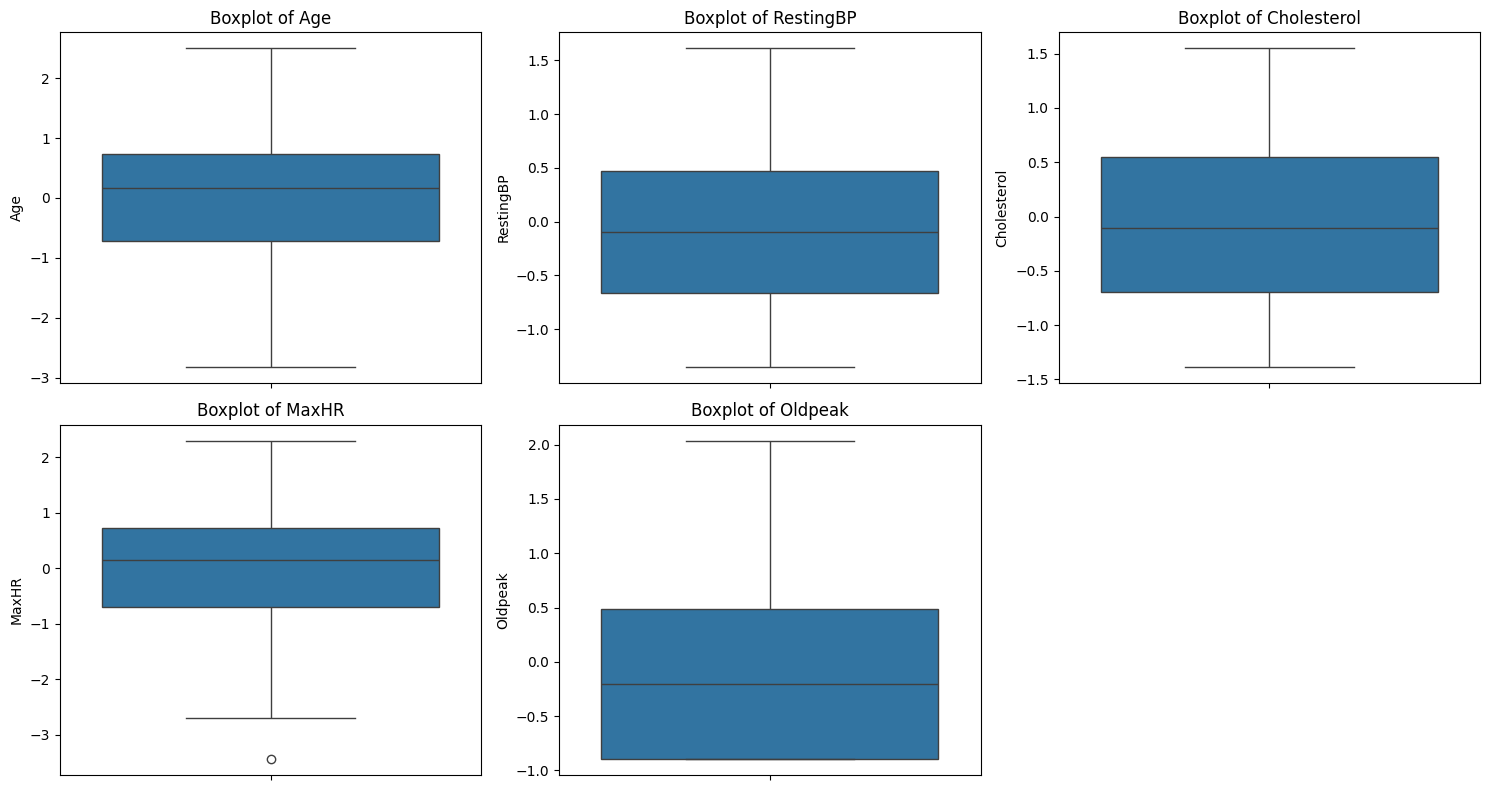

In [ ]:
plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_encoded[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# -> End of This File ->  02_pca_analysis.ipynb